
# itkElastix: Toy Tutorial (Rigid → Affine → B-spline)

This notebook demonstrates a minimal, **fast** multi-stage registration workflow on synthetic images.

### Registration Strategy Explained
We use a common three-stage approach to ensure both broad capture range and fine-scale accuracy:
1.  **Rigid Registration (EulerTransform):** Corrects large-scale rotation and translation. This step is critical for a robust start.
2.  **Affine Registration:** Refines the alignment by adding scaling and shearing, accounting for differences in image size, resolution, and orientation.
3.  **B-spline Refinement (Non-rigid):** Applies local, non-linear deformation to align fine-scale anatomical details missed by the global transforms.

Notes:
- The parameters are tuned for **speed** (small iteration counts, coarse pyramids) to make this a quick toy example. **For real-world accuracy, you would need to increase the number of iterations, maybe use a finer image pyramid, and change parameters.**
- Parameters called out inline with brief explanations.
- I had trouble running ITKElastix with high iteration count in a notebook! For higher iteration count, run a normal python script.

### Imports and image helpers:

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import itk

# Image helpers
def to_itk(img_np):
    img_np = np.ascontiguousarray(img_np.astype(np.float32))
    return itk.GetImageFromArray(img_np)

def to_np(img_itk):
    return itk.GetArrayFromImage(img_itk)

# --- replace show_pair ---
def show_pair(fixed_np, moving_np, alpha=0.5):
    # normalize to [0,1] for display
    f = (fixed_np - fixed_np.min()) / (np.ptp(fixed_np) + 1e-8)
    m = (moving_np - moving_np.min()) / (np.ptp(moving_np) + 1e-8)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(f, cmap='gray'); ax[0].set_title('Fixed');  ax[0].axis('off')
    ax[1].imshow(m, cmap='gray'); ax[1].set_title('Moving'); ax[1].axis('off')

    ax[2].imshow(f, cmap='gray')
    ax[2].imshow(m, alpha=alpha)   # colored overlay on top of fixed
    ax[2].set_title('Overlay: Fixed + Moving'); ax[2].axis('off')
    plt.show()

# --- replace show_overlay ---
def show_overlay(fixed_np, moving_np, registered_np, alpha=0.5):
    # normalize to [0,1] for display
    f = (fixed_np - fixed_np.min()) / (np.ptp(fixed_np) + 1e-8)
    m = (moving_np - moving_np.min()) / (np.ptp(moving_np) + 1e-8)
    r = (registered_np - registered_np.min()) / (np.ptp(registered_np) + 1e-8)

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    ax[0,0].imshow(m, cmap='gray'); ax[0,0].set_title('Moving');     ax[0,0].axis('off')
    ax[0,1].imshow(r, cmap='gray'); ax[0,1].set_title('Registered'); ax[0,1].axis('off')

    ax[1,0].imshow(f, cmap='gray')
    ax[1,0].imshow(m, alpha=alpha)
    ax[1,0].set_title('Overlay BEFORE: Fixed + Moving'); ax[1,0].axis('off')

    ax[1,1].imshow(f, cmap='gray')
    ax[1,1].imshow(r, alpha=alpha)
    ax[1,1].set_title('Overlay AFTER: Fixed + Registered'); ax[1,1].axis('off')

    plt.tight_layout()
    plt.show()


def show_triplet(result_np, fixed_np):
    diff = fixed_np - result_np
    fig, ax = plt.subplots(1, 3, figsize=(12,4))
    ax[0].imshow(result_np, cmap='gray'); ax[0].set_title('Registered'); ax[0].axis('off')
    ax[1].imshow(fixed_np,  cmap='gray'); ax[1].set_title('Fixed');      ax[1].axis('off')
    ax[2].imshow(diff,     cmap='gray'); ax[2].set_title('Difference'); ax[2].axis('off')
    plt.show()



## Create two synthetic images

- Base (fixed) image: simple shapes + gradient.
- Moving image: rotate + translate + small scale + noise.


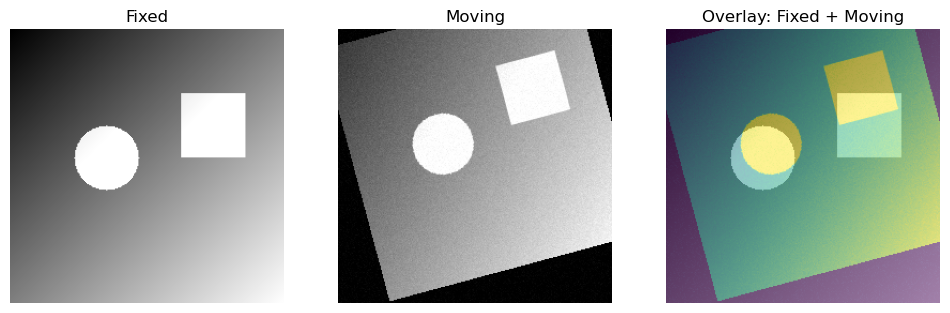

In [2]:

# Generate fixed/moving pair
rs = np.random.RandomState(0)
H, W = 256, 256

# Fixed: circles & rectangles on a soft gradient
yy, xx = np.mgrid[0:H, 0:W]
grad = (yy + xx) / (H + W)
fixed = 0.2 + 0.8*grad
# circle
cy, cx, r = 120, 90, 30
mask_c = (yy-cy)**2 + (xx-cx)**2 <= r**2
fixed[mask_c] += 0.5
# rectangle
fixed[60:120, 160:220] += 0.4
# clamp
fixed = np.clip(fixed, 0, 1)

# Moving: apply a spatial transform (approx) using itk resample for realism
fixed_itk = to_itk(fixed)

# define a small affine (scale ~1.05, rotate ~15deg, translate)
R = np.deg2rad(15)
c, s = np.cos(R), np.sin(R)
scale = 1.05
A = np.array([[scale*c, -scale*s],
              [scale*s,  scale*c]], dtype=np.float64)
t = np.array([20.0, -15.0], dtype=np.float64)  # tx, ty (x,y)

# Build an ITK AffineTransform (2D)
AffineType = itk.AffineTransform[itk.D, 2]
aff = AffineType.New()
M = itk.matrix_from_array(A)
aff.SetMatrix(M)
aff.SetTranslation(t)


moving_itk = itk.resample_image_filter(
    fixed_itk,
    transform=aff,
    size=fixed_itk.GetLargestPossibleRegion().GetSize(),
    output_spacing=fixed_itk.GetSpacing(),
    output_origin=fixed_itk.GetOrigin(),
    output_direction=fixed_itk.GetDirection(),
    default_pixel_value=0.0
)
moving = to_np(moving_itk)

# add noise
moving = np.clip(moving + rs.normal(0, 0.02, moving.shape), 0, 1)
show_pair(fixed, moving)

### Rigid Registration (Euler + ASGD) 
The initial rigid stage (EulerTransform) is the foundation of the registration. It finds the optimal translation and rotation to bring the images close together before any more complex deformations.

**Key Parameters for this Stage:**
* `Transform="EulerTransform"`: The model used for 2D rigid registration (translation + rotation).
* `Metric="AdvancedNormalizedCorrelation"`: A similarity measure optimized for mono-modal (single-modality) images, focusing on matching local patterns.
* `Optimizer="AdaptiveStochasticGradientDescent"`: An efficient, robust optimization algorithm.
* `AutomaticParameterEstimation=true`: Automatically determines the optimizer's main settings (like step size), which is highly recommended for **elastix**.
* `ImageSampler="RandomCoordinate"`: Uses a random subset of pixels for calculation, which significantly speeds up registration compared to using all pixels.
* `ImagePyramidSchedule`: A coarse-to-fine resolution strategy to increase the capture range and refine registration progressively.
* `MaximumNumberOfIterations`: Kept low for this fast, toy example.

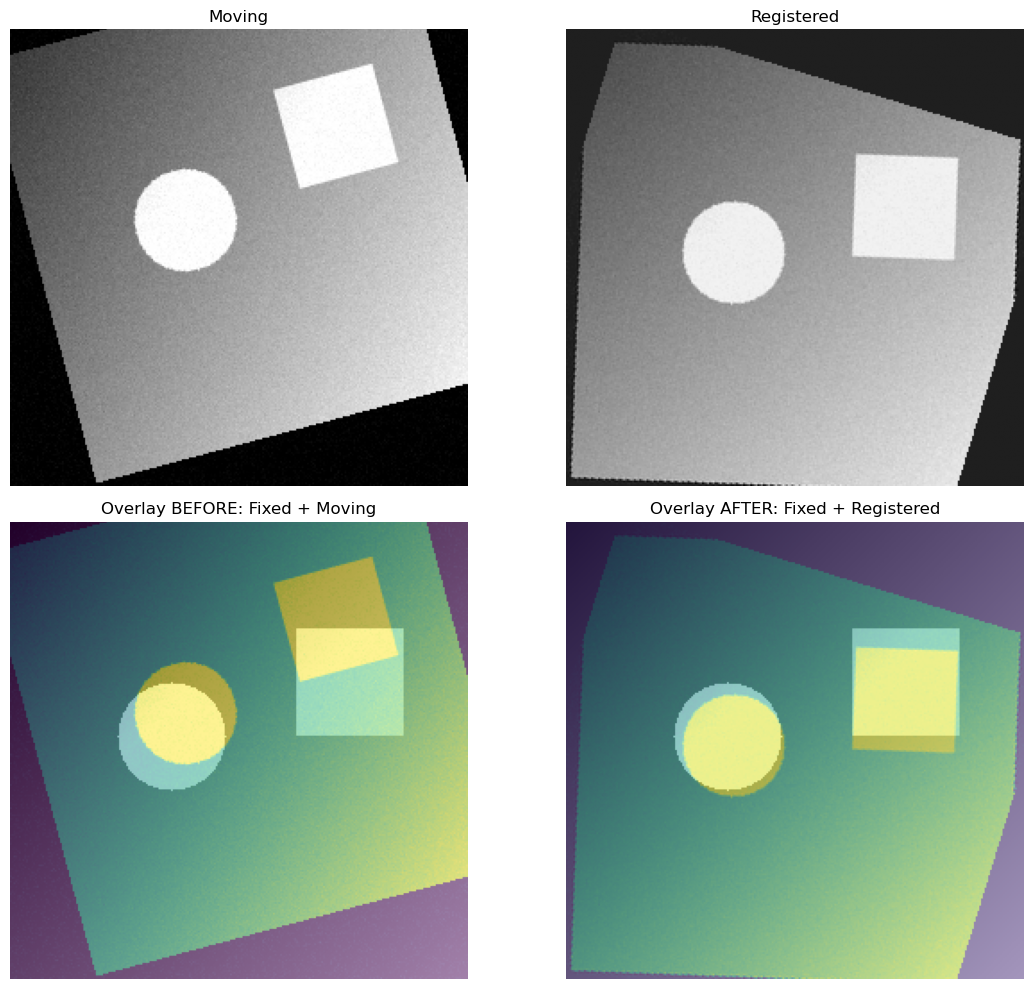

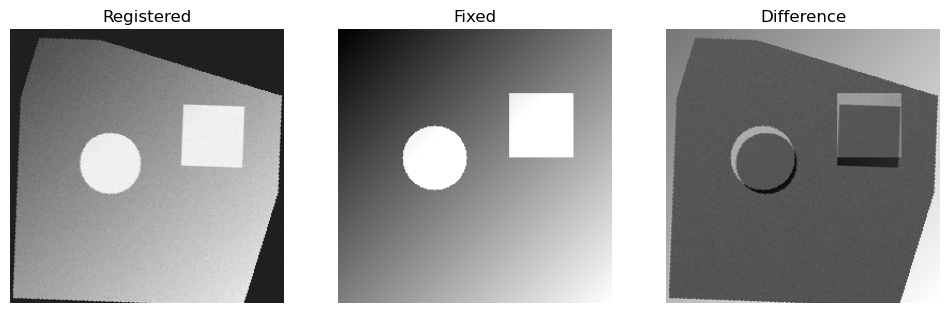

In [3]:
# --- Rigid (Euler) Registration ---

param_obj = itk.ParameterObject.New()

# Rigid registration (Euler + ASGD)
# We request a rigid parameter map, specifying 3 resolution levels for a coarse-to-fine strategy.
rigid = param_obj.GetDefaultParameterMap('rigid', 3)  
# ----------------------------------------------------------------------------------
# 1. Transformation
# ----------------------------------------------------------------------------------
# The EulerTransform is a **rigid** transform: it allows only rotation and translation (no scaling or shearing). 
# It is essential for an initial alignment, as it has few parameters and is less likely to converge to a local minimum.
rigid['Transform'] = ['EulerTransform']

# ----------------------------------------------------------------------------------
# 2. Similarity Metric
# ----------------------------------------------------------------------------------
# AdvancedNormalizedCorrelation (ANC) is a metric that measures the linear correlation between pixel intensities 
# and is robust to linear intensity differences (scaling/offset) between the images. 
# This is a common choice for **mono-modal** (same-modality) registration.
rigid['Metric'] = ['AdvancedNormalizedCorrelation']

# ----------------------------------------------------------------------------------
# 3. Optimizer
# ----------------------------------------------------------------------------------
# AdaptiveStochasticGradientDescent (ASGD) is an efficient optimizer that updates parameters 
# based on a randomly sampled subset of the image data (see ImageSampler below).
rigid['Optimizer'] = ['AdaptiveStochasticGradientDescent']

# This is highly recommended: elastix automatically estimates the optimal parameters for the optimizer (like initial step size)
# based on the transform and the image size, making the registration more robust and easier to configure.
rigid['AutomaticParameterEstimation'] = ['true']

# ----------------------------------------------------------------------------------
# 4. Initialization
# ----------------------------------------------------------------------------------
# Automatically compute an initial guess for the transform before starting the main optimization loop.
rigid['AutomaticTransformInitialization'] = ['true']
# This method finds the center of mass of both images and aligns their centers. 
# It is a robust way to ensure the initial images are roughly centered, which helps registration convergence.
rigid['AutomaticTransformInitializationMethod'] = ['CenterOfGravity']

# ----------------------------------------------------------------------------------
# 5. Image Sampling Strategy (Speed vs. Accuracy)
# ----------------------------------------------------------------------------------
# Instead of using all pixels (which is slow), a RandomCoordinate sampler selects a random subset of pixels 
# in the image to compute the metric (ANC) and its gradient.
rigid['ImageSampler'] = ['RandomCoordinate']
# The number of pixels used for sampling. **Red Flag (Contextual):** This fixed number (15000) 
# is efficient for this small toy image, but for production use, a percentage (e.g., 0.1% of total voxels) 
# or a higher number would be more robust across different image sizes.
rigid['NumberOfSpatialSamples'] = ['15000']
# The maximum number of attempts to find valid (non-background) voxels for sampling.
rigid['MaximumNumberOfSamplingAttempts'] = ['200']
# **Red Flag (Mild):** Setting this to 'false' is 'faster' because the same 15000 samples are reused 
# throughout all iterations of a pyramid level. For more complex, non-rigid registrations, 
# setting this to 'true' (resampling every iteration) can prevent local minima but is slower.
rigid['NewSamplesEveryIteration'] = ['false']

# ----------------------------------------------------------------------------------
# 6. Interpolation and Pyramid
# ----------------------------------------------------------------------------------
# The interpolation order used when reading the moving image. 
# Order 1 (linear interpolation) is a good balance between speed and quality for initial rigid stages.
rigid['BSplineInterpolationOrder'] = ['1']

# This defines the multi-resolution strategy. The schedule has 2 entries per resolution level (for fixed and moving image).
# `16, 16` means the first level downsamples the images by a factor of 16 in all dimensions (very coarse).
# `8, 8` is the second level, and `4, 4` is the third (finest). 
# This very coarse→fine schedule is used to capture large misalignments (translation/rotation) efficiently.
rigid['ImagePyramidSchedule'] = ['16','16','8','8','4','4']

# Iterations per level. **Red Flag (Contextual):** These are very small counts for a fast toy run. 
# For a real-world, production-quality registration, you would need to increase these significantly (e.g., 500-1000+).
rigid['MaximumNumberOfIterations'] = ['250','250','250']
param_obj.AddParameterMap(rigid)

fixed_itk  = to_itk(fixed)
moving_itk = to_itk(moving)

rigid_res, rigid_tx = itk.elastix_registration_method(
    fixed_itk, moving_itk,
    parameter_object=param_obj,
    log_to_console=False
)

rigid_np = to_np(rigid_res)
show_overlay(fixed, moving, rigid_np, alpha=0.5)
show_triplet(rigid_np, fixed)


## Affine registration

Same idea but allow shear/anisotropic scale. Start from scratch (single-stage affine) for simplicity.


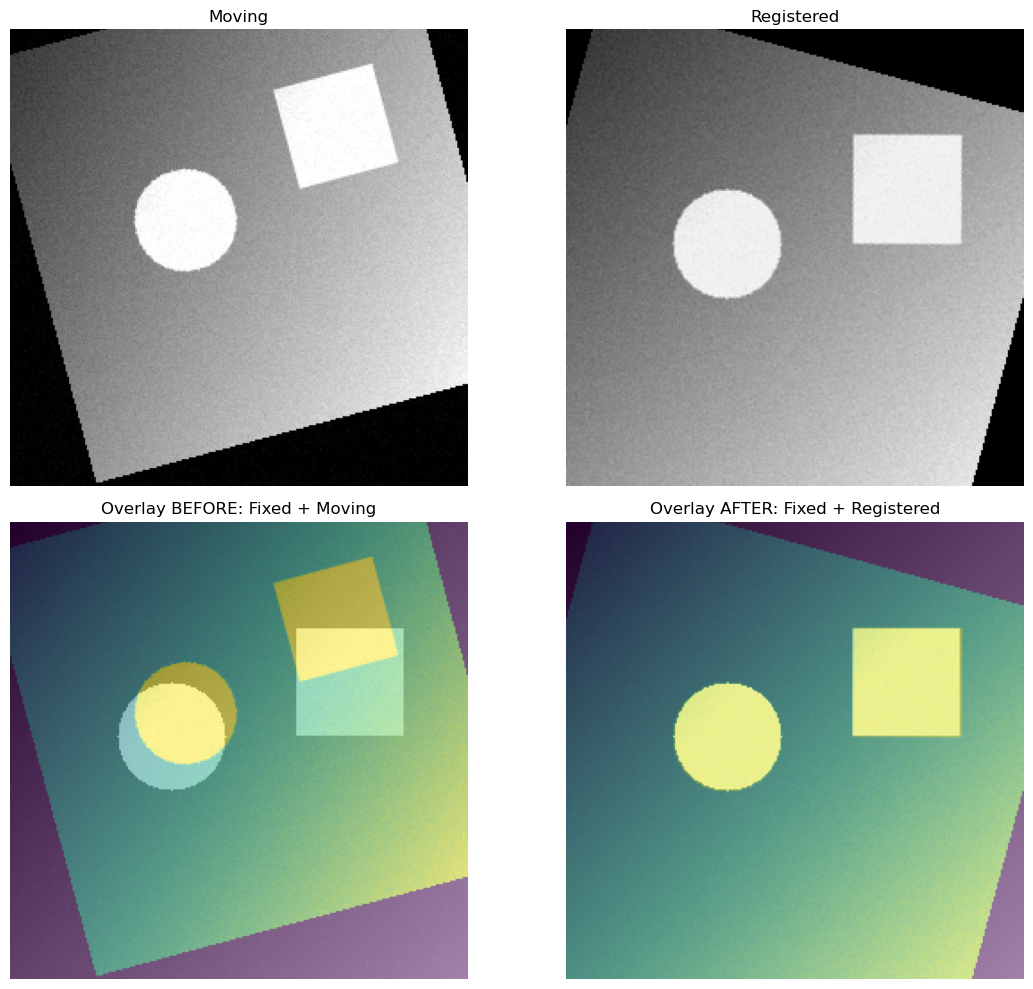

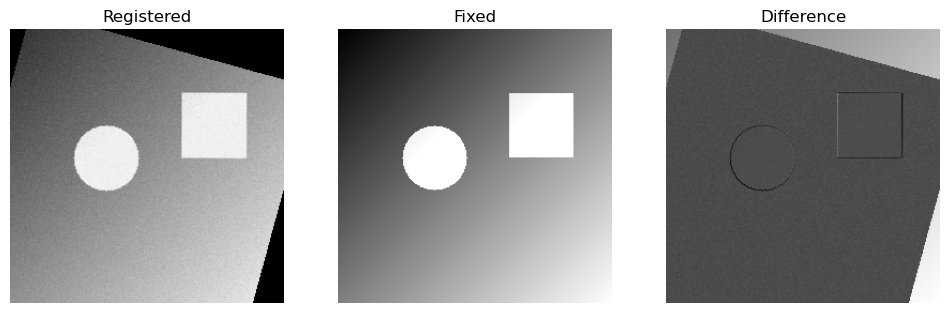

In [4]:

# --- Affine Registration ---
# This stage refines the rigid alignment by allowing scaling and shearing.

param_obj_aff = itk.ParameterObject.New()

# We request a default 'affine' parameter map with 3 resolution levels.
# This map automatically sets the 'Transform' parameter to 'AffineTransform'.
affine = param_obj_aff.GetDefaultParameterMap('affine', 3)

# ----------------------------------------------------------------------------------
# 1. Transformation (The Key Change)
# ----------------------------------------------------------------------------------
# The 'affine' default map uses **AffineTransform**: it allows rotation and translation (like Euler)
# PLUS anisotropic scaling and shearing. This adds complexity but can correct more subtle misalignments.
# (Parameter: Transform, is implicitly set by GetDefaultParameterMap('affine', ...))

# ----------------------------------------------------------------------------------
# 2. Reused Parameters (Metric, Optimizer)
# ----------------------------------------------------------------------------------
# We reuse the same robust metric (AdvancedNormalizedCorrelation) and optimizer (ASGD) as the rigid stage.
affine['Metric'] = ['AdvancedNormalizedCorrelation']
affine['Optimizer'] = ['AdaptiveStochasticGradientDescent']
# Automatic Parameter Estimation is kept 'true' for robustness.
affine['AutomaticParameterEstimation'] = ['true']

# ----------------------------------------------------------------------------------
# 3. Initialization
# ----------------------------------------------------------------------------------
# **Crucial Note/Red Flag:** In a real pipeline, you would use the *output of the rigid stage* as initialization.
# For this simple example, we are using a standalone initialization (CenterOfGravity).
affine['AutomaticTransformInitialization'] = ['true']
affine['AutomaticTransformInitializationMethod'] = ['CenterOfGravity']

# ----------------------------------------------------------------------------------
# 4. Image Sampling Strategy (Minor Change)
# ----------------------------------------------------------------------------------
affine['ImageSampler'] = ['RandomCoordinate']
# The number of samples is slightly increased (from 15000 in rigid to 20000 here) to account 
# for the increased complexity of the affine transform and ensure slightly better sampling.
affine['NumberOfSpatialSamples'] = ['20000']
# Sampling attempts are also increased slightly (from 200 to 300).
affine['MaximumNumberOfSamplingAttempts'] = ['300']
# **Red Flag (Mild):** Sampling is still static ('false') for speed.
affine['NewSamplesEveryIteration'] = ['false']

# ----------------------------------------------------------------------------------
# 5. Interpolation and Pyramid (Same as Rigid)
# ----------------------------------------------------------------------------------
affine['BSplineInterpolationOrder'] = ['1']
# Same coarse-to-fine schedule for a balance of speed and capture range.
affine['ImagePyramidSchedule'] = ['16','16','8','8','4','4']
# **Red Flag (Contextual):** Iterations are still low for this fast toy example.
affine['MaximumNumberOfIterations'] = ['250','250','250']

param_obj_aff.AddParameterMap(affine)

# Execution of the affine registration.
aff_res, aff_tx = itk.elastix_registration_method(
    fixed_itk, moving_itk,
    # In a real pipeline, you would pass initial_transform=rigid_tx here
    parameter_object=param_obj_aff,
    log_to_console=False
)

aff_np = to_np(aff_res)
show_overlay(fixed, moving, aff_np, alpha=0.5)
show_triplet(aff_np, fixed)

### B-spline Refinement (Non-rigid)
This stage refines the globally aligned images with a **non-rigid** deformation to correct fine-scale anatomical mismatches. It is run as a **two-stage sequence** in a single call:

1.  **Stage 1 (Affine):** A quick re-run of the affine alignment (fewer iterations/levels) to ensure the images are perfectly globally aligned.
2.  **Stage 2 (B-spline):** The primary non-rigid deformation is applied, using the output of Stage 1 as its initialization.

**Key Parameters for this Stage:**
* **Chaining:** Two parameter maps (`affine` then `bspline`) are added to the same `ParameterObject`. The result of the first transformation automatically becomes the input for the second.
* `Transform="BSplineTransform"`: Models the deformation as a dense, local field using a grid of control points, enabling non-linear warping.
* `FinalGridSpacingInVoxels`: **Controls the flexibility** of the non-rigid transform. A larger number (e.g., `16`) means a coarse grid, fewer control points, and a faster, less flexible warp (good for a toy example). A smaller number (e.g., `4`) means a dense grid and a more accurate but much slower deformation.
* **Sampler/Metric:** The same `RandomCoordinate` sampler and `AdvancedNormalizedCorrelation` metric are used, but with slightly adjusted counts.


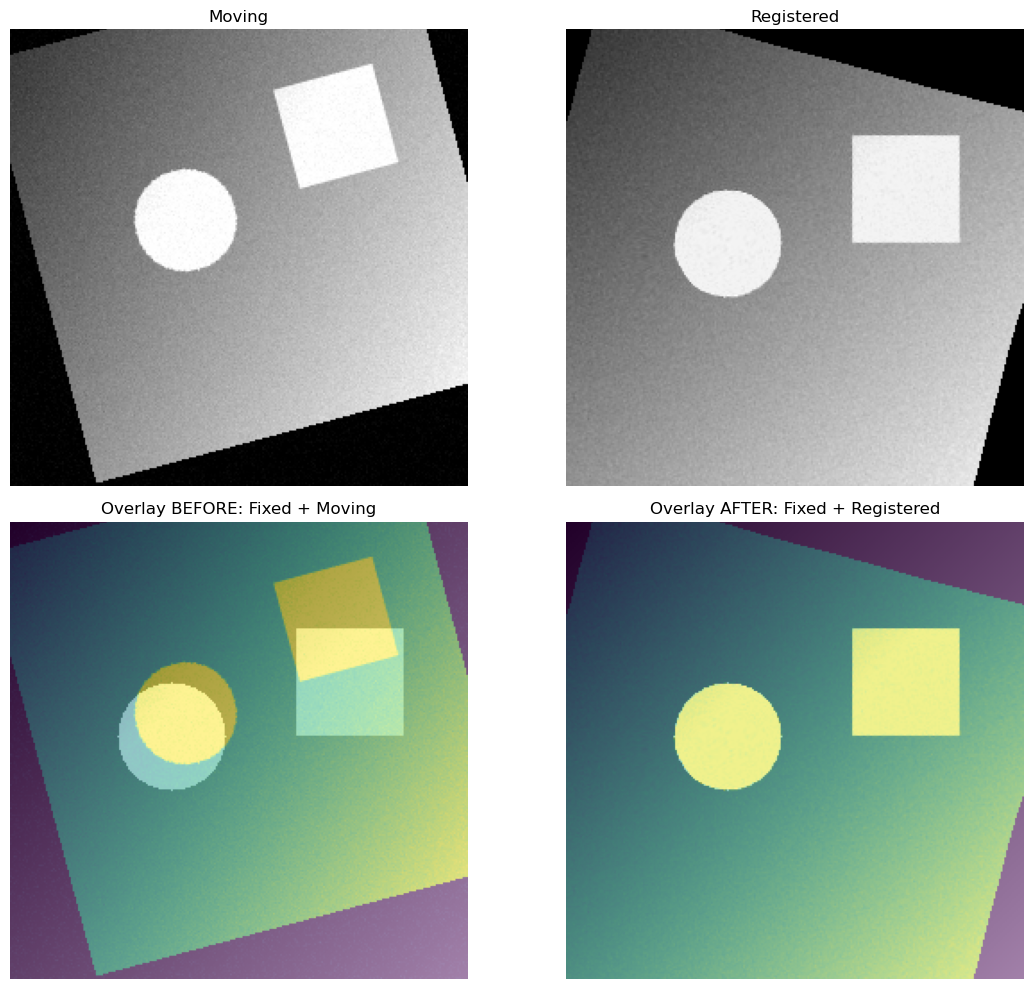

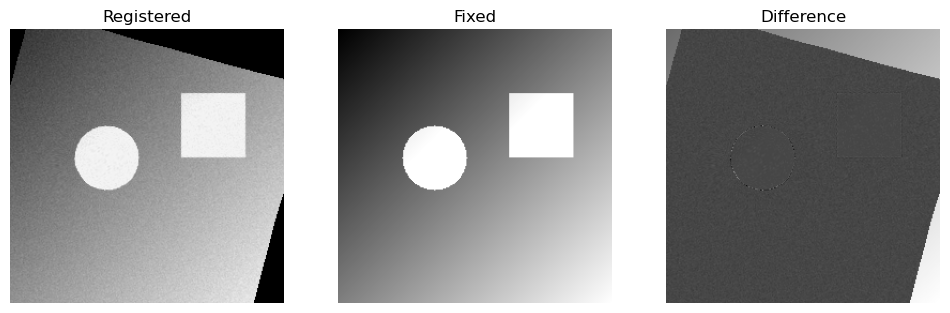

In [5]:
# --- Affine + B-spline refinement (Two-stage Chained Registration) ---
# By adding multiple parameter maps to the same ParameterObject, elastix chains the registration:
# Stage 1 (Affine) is run first. Its result is used as the **initial transform** for Stage 2 (B-spline).

param_obj_combo = itk.ParameterObject.New()

# Stage 1: Affine Pre-Alignment
# We use a 2-level affine map here, simplified from the standalone affine stage (fewer levels and iterations)
# since its main job is just to provide a clean global start for the B-spline.
affine2 = param_obj_combo.GetDefaultParameterMap('affine', 2)
affine2['Metric'] = ['AdvancedNormalizedCorrelation']
affine2['Optimizer'] = ['AdaptiveStochasticGradientDescent']
affine2['AutomaticParameterEstimation'] = ['true']
# Initialization is set to CenterOfGravity, but since this is the *first* stage in the combo, 
# it effectively initializes from scratch or a default identity transform.
affine2['AutomaticTransformInitialization'] = ['true'] 
affine2['AutomaticTransformInitializationMethod'] = ['CenterOfGravity']
affine2['ImageSampler'] = ['RandomCoordinate']
affine2['NumberOfSpatialSamples'] = ['15000']
affine2['MaximumNumberOfSamplingAttempts'] = ['200']
affine2['NewSamplesEveryIteration'] = ['false']
affine2['BSplineInterpolationOrder'] = ['1']
# Coarser 2-level pyramid schedule for speed.
affine2['ImagePyramidSchedule'] = ['8','8','4','4']    
# Fewer iterations, as this is a quick setup stage before the main B-spline work.
affine2['MaximumNumberOfIterations'] = ['200','200']
param_obj_combo.AddParameterMap(affine2)

# Stage 2: B-spline Non-Rigid Refinement
# This uses the BSplineTransform, which warps the image using a grid of control points.
bs = param_obj_combo.GetDefaultParameterMap('bspline', 2)
# Since the image is already well-aligned globally (from Stage 1), we can reuse the same settings.
bs['Metric'] = ['AdvancedNormalizedCorrelation']
bs['Optimizer'] = ['AdaptiveStochasticGradientDescent']
bs['AutomaticParameterEstimation'] = ['true']
bs['ImageSampler'] = ['RandomCoordinate']
bs['NumberOfSpatialSamples'] = ['20000']
bs['MaximumNumberOfSamplingAttempts'] = ['200']
bs['NewSamplesEveryIteration'] = ['false']
bs['BSplineInterpolationOrder'] = ['1']

# --- B-SPLINE SPECIFIC PARAMETERS ---
# 'FinalGridSpacingInVoxels' is the **most important** parameter for non-rigid speed/flexibility.
# It defines the distance (in voxels) between the control points of the B-spline grid.
# Coarse grid (large number, e.g., 16) = fewer control points, faster, less flexible/detailed deformation.
# Fine grid (small number, e.g., 4) = many control points, slower, highly detailed deformation.
# The default map often calculates this automatically, but you can uncomment and set it for explicit control:
# bs['FinalGridSpacingInVoxels'] = ['16'] 

# A modest 2-level pyramid for refinement. We start at a level 4 downsampling and refine to level 2.
bs['ImagePyramidSchedule'] = ['4','4','2','2']
# **Red Flag (Contextual):** Iterations are set low (150 per level) for this fast toy example. 
# Real-world non-rigid registration often requires much higher iteration counts (e.g., 500-1000+) to converge.
bs['MaximumNumberOfIterations'] = ['150','150']

param_obj_combo.AddParameterMap(bs)

# Execution: elastix runs Stage 1, then uses its output to initialize Stage 2.
bs_res, bs_tx = itk.elastix_registration_method(
    fixed_itk, moving_itk,
    parameter_object=param_obj_combo,
    log_to_console=False
)

bs_np = to_np(bs_res)
show_overlay(fixed, moving, bs_np, alpha=0.5)
show_triplet(bs_np, fixed)

### 3D Registration Example: Affine → B-spline (Chained)

This section extends the concepts to 3D. The registration strategy remains the same (global alignment followed by non-rigid refinement), but the parameter maps now implicitly use 3D transforms (`AffineTransform` and `BSplineTransform`).

**Key Differences for 3D Parameters:**

* **Pyramid Schedule:** The `ImagePyramidSchedule` now requires **three** entries per resolution level (for the X, Y, and Z dimensions), which is why we see schedules like `8,8,8,4,4,4`.
* **Sampling:** The 3D volume is much larger, so the number of spatial samples (`NumberOfSpatialSamples`) is increased (e.g., to $30,000$ or $40,000$) to maintain good coverage.
* **B-spline Grid:** Since the image is 3D, the B-spline control grid is now a cube. A `FinalGridSpacingInVoxels` of `12` in a 3D context represents a very coarse grid for a fast, simple deformation.

---

#### 3D Affine Stage (Pre-Alignment)
This stage finds the 12 degrees of freedom (3 translation, 3 rotation, 3 scaling, 3 shearing) required for a global 3D alignment.

| Parameter | 3D Value | Explanation |
| :--- | :--- | :--- |
| `Transform` | `AffineTransform` (implicit) | Corrects 3D rotation, translation, scaling, and shear. |
| `NumberOfSpatialSamples` | `30000` | Increased sample count for the larger 3D volume. |
| `ImagePyramidSchedule` | `8,8,8,4,4,4` | Coarse 2-level schedule: starts with $8\times 8\times 8$ downsampling. |
| `MaximumNumberOfIterations`| `150, 150` | Low iteration counts for speed (toy example). |

#### 3D B-spline Stage (Non-rigid Refinement)
This stage performs the final non-rigid warp.

| Parameter | 3D Value | Explanation |
| :--- | :--- | :--- |
| `Transform` | `BSplineTransform` (implicit) | Allows local, non-linear deformation defined by a 3D grid. |
| `FinalGridSpacingInVoxels`| `12` | Defines the coarse spacing (12 voxels) between B-spline control points for a fast warp. |
| `ImagePyramidSchedule` | `4,4,4,2,2,2` | 2-level pyramid for refinement: starts at $4\times 4\times 4$ downsampling. |

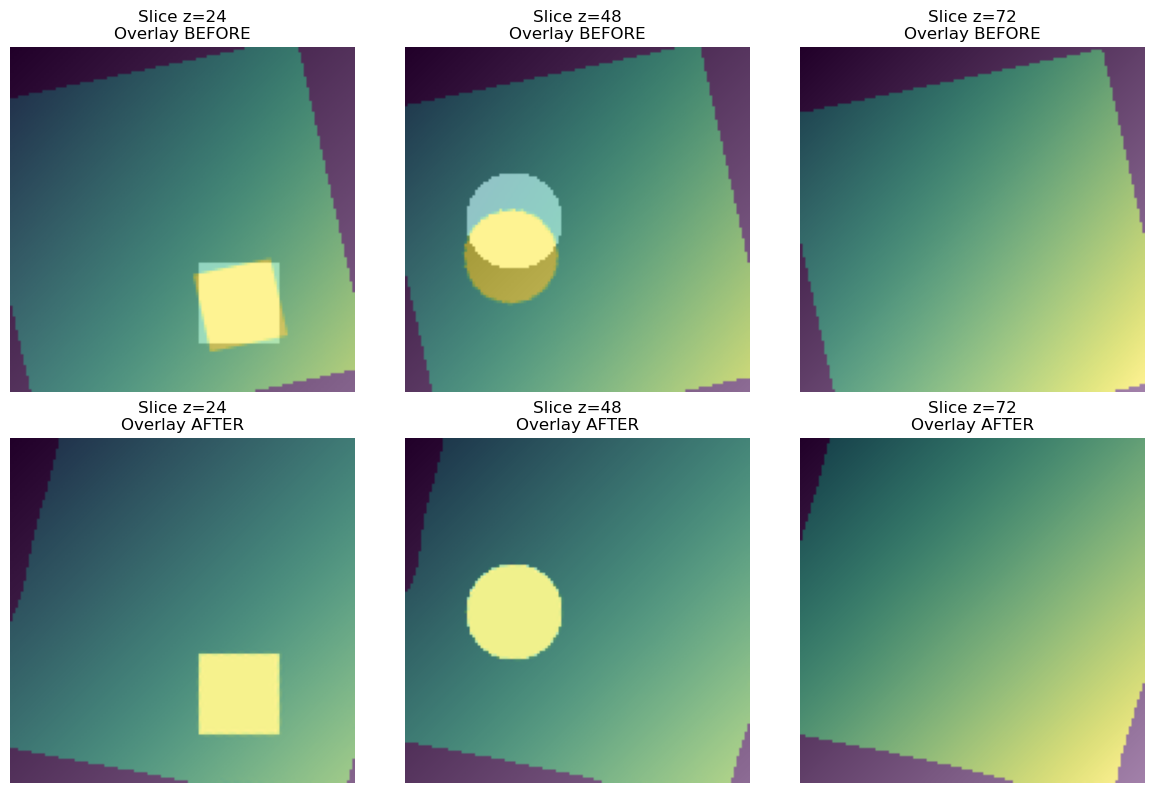

In [6]:
# helpers for 3D
def to_itk3(img_np):
    img_np = np.ascontiguousarray(img_np.astype(np.float32))
    return itk.GetImageFromArray(img_np)

def to_np3(img_itk):
    return itk.GetArrayFromImage(img_itk)

def show_axial_overlays_3d(fixed3, moving3, registered3=None, z_slices=None, alpha=0.5):
    Z = fixed3.shape[0]
    if z_slices is None:
        z_slices = [Z // 4, Z // 2, 3 * Z // 4]
    
    # We will plot (Before Overlay, After Overlay) for each slice
    ncols = len(z_slices)
    fig, ax = plt.subplots(2, ncols, figsize=(4 * ncols, 8), squeeze=False)    

    for i, z in enumerate(z_slices):
        f = fixed3[z]; m = moving3[z]
        # Normalize slices for visualization
        f = (f - f.min()) / (np.ptp(f) + 1e-8)
        m = (m - m.min()) / (np.ptp(m) + 1e-8)

        # Row 1: Overlay BEFORE Registration
        ax[0, i].imshow(f, cmap='gray')
        ax[0, i].imshow(m, alpha=alpha)
        ax[0, i].set_title(f'Slice z={z}\nOverlay BEFORE')
        ax[0, i].axis('off')
        
        # Row 2: Overlay AFTER Registration (if available)
        if registered3 is not None:
            r = registered3[z]; r = (r - r.min()) / (np.ptp(r) + 1e-8)
            ax[1, i].imshow(f, cmap='gray')
            ax[1, i].imshow(r, alpha=alpha)
            ax[1, i].set_title(f'Slice z={z}\nOverlay AFTER')
            ax[1, i].axis('off')
        else:
            # If no registration result, show fixed image for context
            ax[1, i].imshow(f, cmap='gray')
            ax[1, i].set_title(f'Slice z={z}\nFixed Image')
            ax[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# build synthetic 3D fixed
Z, Y, X = 96, 128, 128
zz, yy, xx = np.mgrid[0:Z, 0:Y, 0:X]
grad3 = (zz + yy + xx) / (Z + Y + X)
fixed3 = 0.2 + 0.8*grad3
fixed3[(zz-50)**2 + (yy-64)**2 + (xx-40)**2 <= 18**2] += 0.6
fixed3[20:40, 80:110, 70:100] += 0.5
fixed3 = np.clip(fixed3, 0, 1)
fixed3_itk = to_itk3(fixed3)

# make moving via 3D affine
Rz = np.deg2rad(12.0); Ry = np.deg2rad(-7.0); Rx = np.deg2rad(5.0)
def Rxm(a): ca, sa = np.cos(a), np.sin(a); return np.array([[1,0,0],[0,ca,-sa],[0,sa,ca]])
def Rym(a): ca, sa = np.cos(a), np.sin(a); return np.array([[ca,0,sa],[0,1,0],[-sa,0,ca]])
def Rzm(a): ca, sa = np.cos(a), np.sin(a); return np.array([[ca,-sa,0],[sa,ca,0],[0,0,1]])
R = Rzm(Rz) @ Rym(Ry) @ Rxm(Rx)
A3 = 1.03 * R
t3 = np.array([6.0, -8.0, 4.0])  # (z,y,x)
Affine3 = itk.AffineTransform[itk.D, 3].New()
Affine3.SetMatrix(itk.matrix_from_array(A3))
Affine3.SetTranslation([float(t3[2]), float(t3[1]), float(t3[0])])  # (x,y,z)
center_idx = (int(X/2), int(Y/2), int(Z/2))
center_phys = to_itk3(fixed3).TransformIndexToPhysicalPoint(center_idx)
Affine3.SetCenter(center_phys)

moving3_itk = itk.resample_image_filter(
    to_itk3(fixed3),
    transform=Affine3,
    size=to_itk3(fixed3).GetLargestPossibleRegion().GetSize(),
    output_spacing=to_itk3(fixed3).GetSpacing(),
    output_origin=to_itk3(fixed3).GetOrigin(),
    output_direction=to_itk3(fixed3).GetDirection(),
    default_pixel_value=0.0
)
moving3 = to_np3(moving3_itk)

# register 3D: affine -> bspline
# --- 3D Registration: Affine -> B-spline (Chained) ---
param3 = itk.ParameterObject.New()

# Stage 1: 3D Affine Pre-alignment (Implicitly uses AffineTransform[D, 3])
aff3 = param3.GetDefaultParameterMap('affine', 2)
aff3['Metric'] = ['AdvancedNormalizedCorrelation']
aff3['Optimizer'] = ['AdaptiveStochasticGradientDescent']
aff3['AutomaticParameterEstimation'] = ['true']
aff3['AutomaticTransformInitialization'] = ['true']
aff3['AutomaticTransformInitializationMethod'] = ['CenterOfGravity']
aff3['ImageSampler'] = ['RandomCoordinate']
# Increased samples for the larger 3D volume
aff3['NumberOfSpatialSamples'] = ['30000'] 
aff3['MaximumNumberOfSamplingAttempts'] = ['500']
aff3['NewSamplesEveryIteration'] = ['false']
aff3['BSplineInterpolationOrder'] = ['1']
# 3D pyramid schedule (3 entries per level: Z, Y, X). Starts coarse (8x downsampling).
aff3['ImagePyramidSchedule'] = ['8','8','8','4','4','4']
# Low iterations for fast toy example.
aff3['MaximumNumberOfIterations'] = ['150','150']
param3.AddParameterMap(aff3)

# Stage 2: 3D B-spline Non-Rigid Refinement (Implicitly uses BSplineTransform[D, 3])
bs3 = param3.GetDefaultParameterMap('bspline', 2)
bs3['Metric'] = ['AdvancedNormalizedCorrelation']
bs3['Optimizer'] = ['AdaptiveStochasticGradientDescent']
bs3['AutomaticParameterEstimation'] = ['true']
bs3['ImageSampler'] = ['RandomCoordinate']
# Further increased samples for the non-rigid, more detailed stage
bs3['NumberOfSpatialSamples'] = ['40000']
bs3['MaximumNumberOfSamplingAttempts'] = ['500']
bs3['NewSamplesEveryIteration'] = ['false']
bs3['BSplineInterpolationOrder'] = ['1']

# B-spline specific parameter control: ensure we use Voxel units
if 'FinalGridSpacingInPhysicalUnits' in bs3:
    # We delete the physical units setting if it exists to ensure the next line takes effect
    del bs3['FinalGridSpacingInPhysicalUnits'] 
# Controls the non-rigid flexibility: 12 voxels spacing = coarse grid, faster, less detailed.
# (Red Flag Contextual: This should be much smaller, e.g., 4 or 6, for production-quality detailed warp)
bs3['FinalGridSpacingInVoxels'] = ['12']

# Modest 2-level pyramid for refinement
bs3['ImagePyramidSchedule'] = ['4','4','4','2','2','2']
# Low iterations for fast toy example.
bs3['MaximumNumberOfIterations'] = ['120','120']
param3.AddParameterMap(bs3)

# Execute the 3D registration pipeline
res3_itk, tx3 = itk.elastix_registration_method(
    to_itk3(fixed3), to_itk3(moving3), 
    parameter_object=param3, 
)
res3 = to_np3(res3_itk)

# CHANGED: Use the updated plotting function with multiple slices for better visual analysis.
Z_dim = fixed3.shape[0]
show_axial_overlays_3d(fixed3, moving3, res3, z_slices=[Z_dim//4, Z_dim//2, 3*Z_dim//4], alpha=0.5)